# Tracking My Chess Career Through Blitz, Rapid, and Bullet

By Tom White, 4/20/2026


My dataset comes from a personal Chess.com export and is stored as a CSV file. From that raw file, I built three tables:

- games_clean.csv: one row per blitz, rapid, or bullet game.
- calendar_table.csv: one row per active date with weekday and weekly grouping fields.
- daily_summary.csv: one row per active date with aggregated results.

BIG question: Which patterns in my Chess.com blitz, rapid, and bullet games show my biggest strengths and weaknesses?


In [1]:
import utils
import pandas as pd

games, calendar, daily = utils.load_data()

utils.dataset_table_overview(games, calendar, daily)
utils.project_scope_summary_df(games, daily)
utils.time_control_distribution(games)

Dataset Table Overview:
                table  rows  columns
0     games_clean.csv  1623       40
1  calendar_table.csv   331        8
2   daily_summary.csv   331       20

Project Scope Summary:
                         metric       value
0                Games analyzed        1623
1                   Active days         331
2                    First date  2021-04-09
3                     Last date  2025-09-06
4              Overall win rate       0.586
5  Average games per active day         4.9

Time Control Distribution:
  timeClass  games     share
0     rapid    678  0.417745
1     blitz    596  0.367221
2    bullet    349  0.215034



The cleaned dataset contains 1,623 games across 331 active dates from April 9, 2021 through September 6, 2025. The overall win rate was 58.6%. Rapid has the largest share of games, followed by blitz and bullet, which gives the project enough coverage for descriptive analysis.

## Data Preparation

I cleaned the export by keeping only blitz, rapid, and bullet games, parsing dates and times, fixing missing values, and creating features such as win/loss, rating difference, opponent strength, time of day, opening family, and games already played that day.

In [2]:
print(games[
        [
            "date",
            "timeClass",
            "userColor",
            "userRating",
            "opponentRating",
            "move_count",
            "terminal_outcome",
            "opening_family",
            "games_played_so_far_today",
            "weekday",
            "hour_bucket_et",
        ]
    ].head(5))

        date timeClass userColor  userRating  opponentRating  move_count  \
0 2021-04-09    bullet     white         247             499        17.0   
1 2021-04-09     rapid     black         593             420        44.0   
2 2021-04-10     rapid     black         467             596        10.0   
3 2021-04-10     rapid     white         373             466        36.0   
4 2021-04-10     rapid     white         308             418        52.0   

  terminal_outcome                              opening_family  \
0          timeout  Nimzowitsch Defense Kennedy Paulsen Attack   
1          timeout             Ruy Lopez Opening Cozio Defense   
2         resigned     Queens Gambit Declined Chigorin Defense   
3          timeout                                 Scotch Game   
4       checkmated  Sicilian Defense Smith Morra Morphy Gambit   

   games_played_so_far_today   weekday hour_bucket_et  
0                          0    Friday        evening  
1                          1    Fr

## Exploratory Data Analysis

I used game-level aggregation for openings, color, opponent strength, time control, and time of day. I used day-level aggregation for longer trends, including rating and games played per week.

The first plots show rating progression and weekly activity over time.

<Axes: title={'center': 'Games Played Per Week by Time Control'}, xlabel='Week Starting', ylabel='Games Played'>

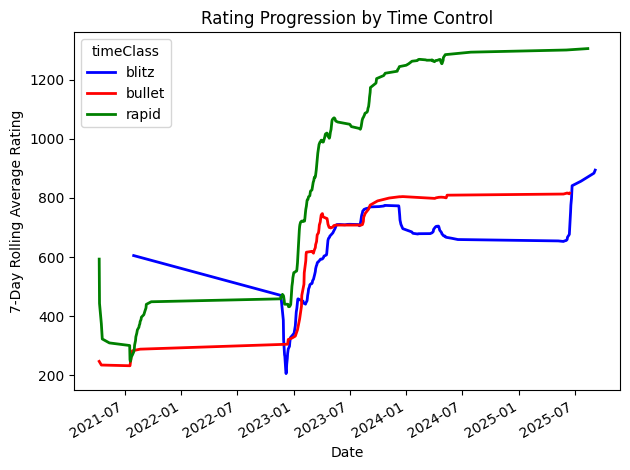

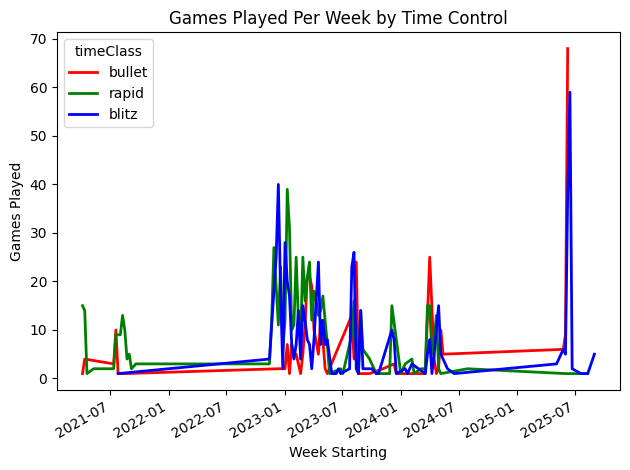

In [ ]:
utils.plot_rating_progression(games) 
utils.plot_games_per_week(games)  

### White vs Black Performance

White and Black performance were very close: 59.2% vs 58.0% using all games.

<Axes: title={'center': 'Win Rate by Color'}, xlabel='Color', ylabel='Win Rate'>

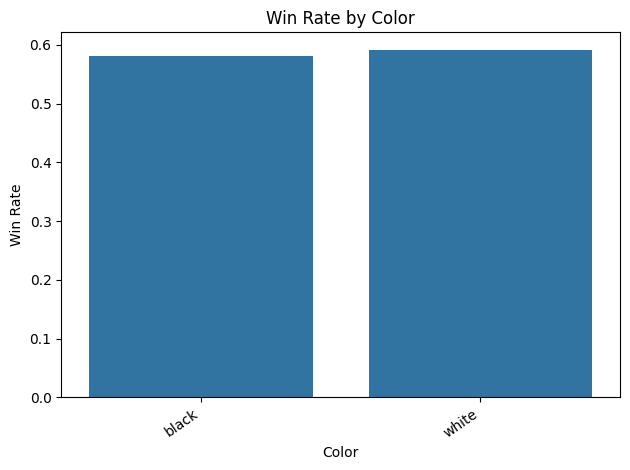

In [4]:
utils.plot_win_rate_by_color(games)

### Win Rates by Time Control

Rapid had the highest win rate at about 59.9%, followed by bullet at 58.5% and blitz at 57.2%.

<Axes: title={'center': 'Win Rate by Time Control'}, xlabel='Time Control', ylabel='Win Rate'>

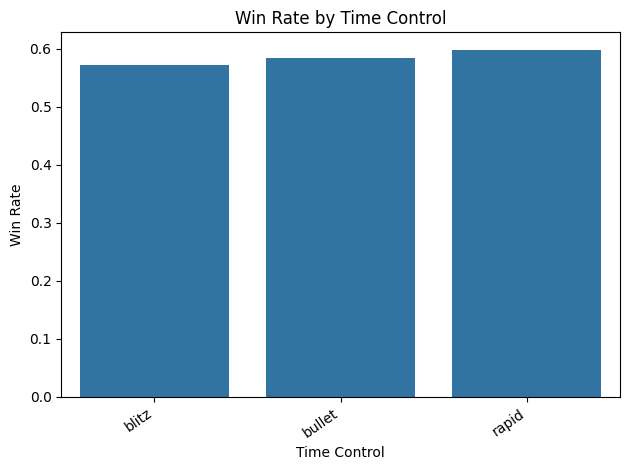

In [5]:
utils.plot_win_rate_by_time_control(games)

### Win Rate by Opponent Strength

Win rate changed the most with opponent strength, which makes sense. I won 75.6% against slightly lower-rated opponents but only 14.3% against opponents 100+ points higher.

<Axes: title={'center': 'Win Rate by Opponent Strength Bucket'}, xlabel='Opponent Strength Bucket', ylabel='Win Rate'>

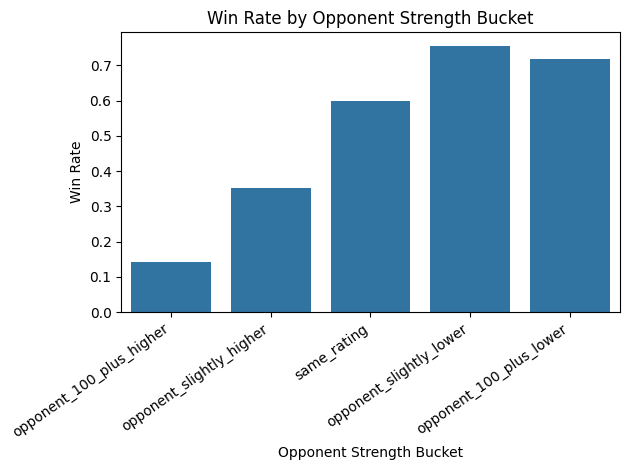

In [6]:
utils.plot_win_rate_by_opponent_strength(games)

### Win Rates by Time of Day

Afternoon was my best time bucket at 59.8%, while morning was lowest at 55.3%, though morning had only 38 games.

<Axes: title={'center': 'Win Rate by Time of Day (ET)'}, xlabel='Time of Day', ylabel='Win Rate'>

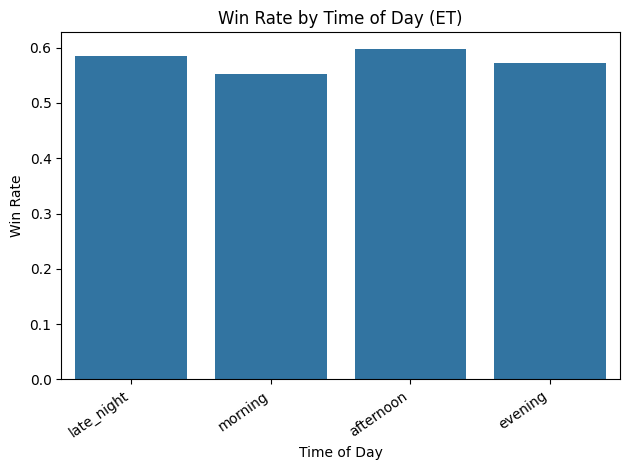

In [7]:
utils.plot_win_rate_by_time_of_day(games)

### Chess Openings

My weakest White opening group was French Defense Knight Variation at 33.3%. As Black, Giuoco Piano Game was lowest at 37.5%, so openings are my clearest improvement target.

In [8]:
white_openings = utils.weakest_openings(games,"white")
black_openings = utils.weakest_openings(games,"black")

print(white_openings[["opening_family", "win_rate"]].head(10))
print("\n")
print(black_openings[["opening_family", "win_rate"]].head(10))

                                      opening_family  win_rate
0                    French Defense Knight Variation  0.333333
1  Ponziani Opening Jaenisch Counterattack 4.d4 exd4  0.416667
2                       Ponziani Opening 3...d6 4.d4  0.421053
3                                 Kings Pawn Opening  0.454545
4                                   Philidor Defense  0.500000
5  Scandinavian Defense Mieses Kotrc Variation 3.Nc3  0.500000
6          Kings Pawn Opening Kings Knight Variation  0.533333
7                                     Englund Gambit  0.545455
8  Queens Pawn Opening Accelerated London System ...  0.545455
9          Queens Pawn Opening Horwitz Defense 2.Bf4  0.545455


                                     opening_family  win_rate
0                                 Giuoco Piano Game  0.375000
1                       Van t Kruijs Opening 1...e5  0.416667
2                                       Center Game  0.466667
3                                      Italian Game  0.46

Hypothesis Testing:

Hypothesis 1: White vs Black win rate (two-proportion z-test)

$H_0$ = Win rate (White) equals Win Rate (Black).  
$H_1$ = Win rate (White) does not equal Win rate (Black)

For decisive games only, White won 62.5% and Black won 61.3%. The p-value was 0.640, so I fail to reject the null hypothesis. There is not strong evidence that color meaningfully affected my win rate.


In [9]:
hypothesis_test = utils.run_hypothesis_test(games)
print(pd.DataFrame(hypothesis_test))

   white_win_rate  black_win_rate  z_stat   p_value  significant_at_0_05
0           0.625        0.613402   0.468  0.639785                False


## Classification Results

### Target attribute
The class label is result_group (win vs loss). Draws are excluded so the task is a clean binary classification. Each game is labeled 1 (win) or 0 (loss).

### Model features:
- opponent_rating
- rating_diff
- time_control
- color
- games_played_that_day  
- recent_streak

### Class distribution
The dataset is moderately imbalanced: roughly 62% wins and 38% losses (after removing draws). This means a naive majority-class baseline would score about 62%.

### Hypotheses
1. Rating difference should be the strongest single predictor of a win, since higher-rated opponents are harder to beat.
2. Opening family may add some predictive value because certain openings have clearly lower win rates.
3. Time of day and day of week probably have limited predictive power based on the EDA.
4. Decision Tree should outperform kNN on this dataset because the features include a mix of categorical and numeric columns, and tree-based models handle mixed types better.

### Evaluation
Both classifiers are evaluated with a 75/25 train/test split


Class Label Distribution (win vs loss, draws excluded):
              count  percent
result_group                
win             951    61.91
loss            585    38.09

kNN Classifier (neighbors=5)
  Accuracy: 0.6823
Decision Tree Classifier (max_depth=5)
  Accuracy: 0.7344


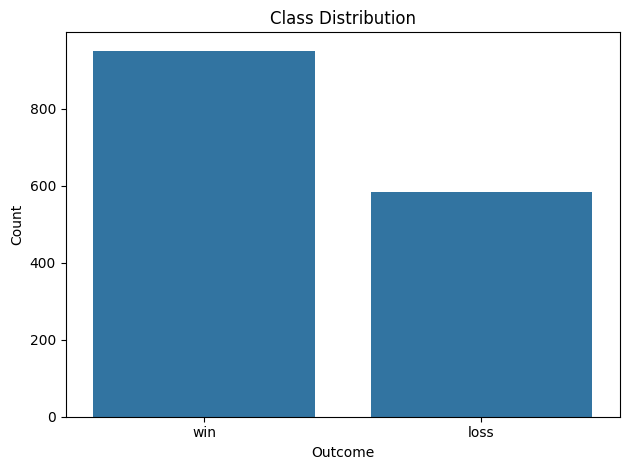

In [10]:
utils.class_label_distribution(games)
utils.plot_class_distribution(games)

knn_results = utils.run_knn_classifier(games, k=5)
dt_results = utils.run_decision_tree_classifier(games, max_depth=5)

<Axes: title={'center': 'Classifier Accuracy Comparison'}, xlabel='Classifier', ylabel='Accuracy'>

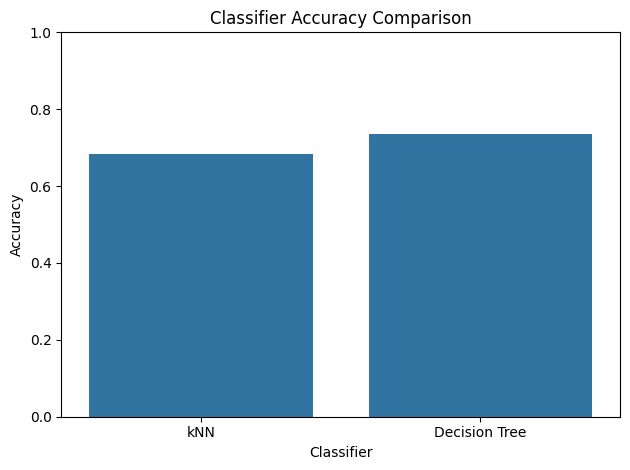

In [11]:
utils.plot_classifier_comparison(knn_results, dt_results)

<Axes: title={'center': 'Decision Tree (first 3 levels)'}>

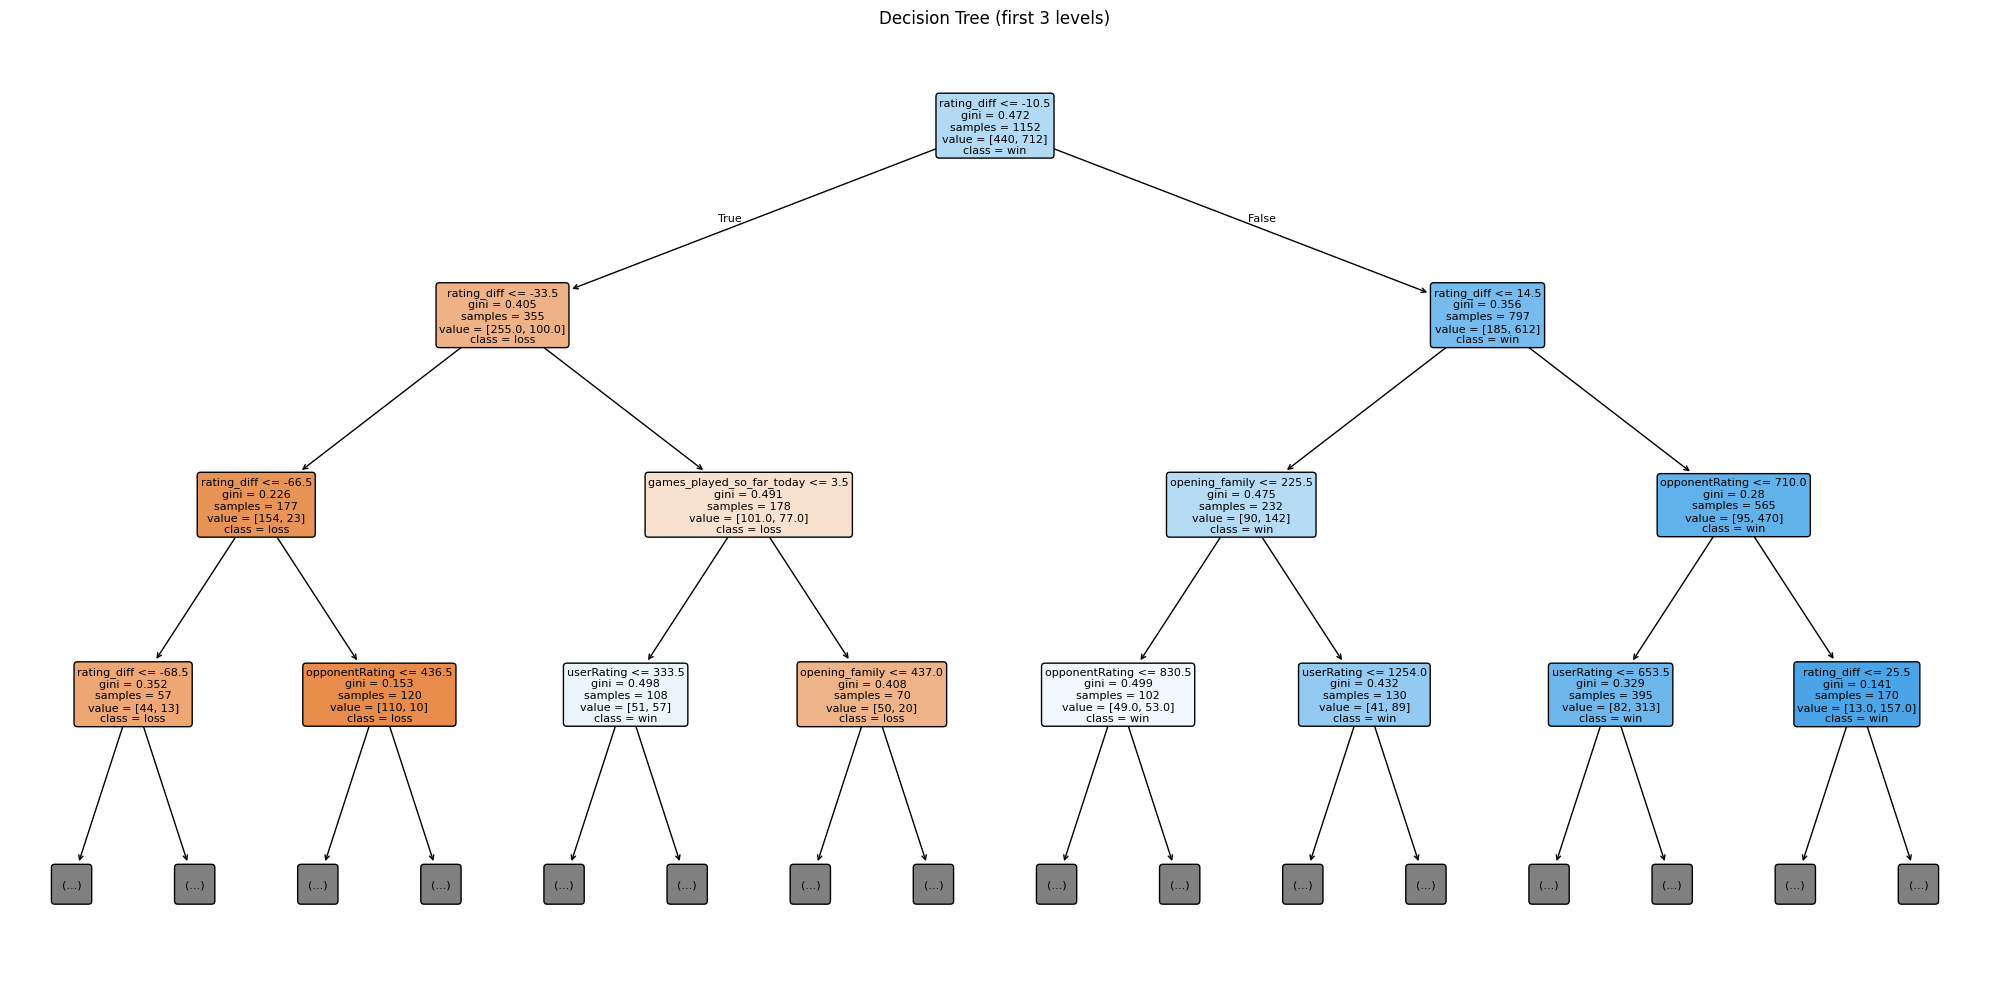

In [12]:
utils.plot_decision_tree(dt_results)

### Results comparison

The Decision Tree achieved about 73.4% accuracy versus 68% for kNN, both above the 62% majority-class baseline. Rating difference dominated the Decision Tree's feature importances at roughly 75%, confirming the first hypothesis.

### Challenges

1. Class imbalance: With 62% wins, both models tended to over-predict the majority class.
2. Categorical features: kNN treats label-encoded categories as ordinal numbers, which introduces artificial distance relationships. Decision Tree does not suffer from this issue.
3. Feature dominance: rating_diff is so predictive that other features contribute very little. The models are essentially learning the rating gap.
4. Small dataset: With only about 1,500 decisive games, overfitting is a risk, especially for the Decision Tree without depth limits.


## Conclusion

Overall, my results suggest that color was not a major factor in my performance. The biggest differences I noticed came from opponent strength, time control, and specific openings. The most useful takeaway here is that I should focus study time on the opening families where my win rate was lowest, especially the French Defense Knight Variation as White.  

The classification models confirmed that rating difference is the dominant factor in predicting wins, with both kNN and Decision Tree beating the majority-class baseline by about 10 percentage points.
